<a href="https://colab.research.google.com/github/Ansarss/Ai_learning_experiments/blob/main/jpmorgan_equity_etf_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rajkumarpandey02/jpmorgan-equity-premium-income-etf-jepi")

print("Path to dataset files:", path)

100%|██████████| 18.1k/18.1k [00:00<00:00, 14.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rajkumarpandey02/jpmorgan-equity-premium-income-etf-jepi/versions/1


In [4]:
import os

print("Dataset path:", path)

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Dataset path: /root/.cache/kagglehub/datasets/rajkumarpandey02/jpmorgan-equity-premium-income-etf-jepi/versions/1
/root/.cache/kagglehub/datasets/rajkumarpandey02/jpmorgan-equity-premium-income-etf-jepi/versions/1/JPMorgan Equity Premium Income ETF (JEPI).csv


In [5]:
file_path = "/root/.cache/kagglehub/datasets/rajkumarpandey02/jpmorgan-equity-premium-income-etf-jepi/versions/1/JPMorgan Equity Premium Income ETF (JEPI).csv"

df = pd.read_csv(file_path)

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-05-21 00:00:00-04:00,50.029999,50.130001,49.860001,49.935001,39.583023,6200
1,2020-05-22 00:00:00-04:00,49.930000,50.099998,49.889999,50.094002,39.709068,9500
2,2020-05-26 00:00:00-04:00,50.500000,50.599998,50.237999,50.237999,39.823208,5600
3,2020-05-27 00:00:00-04:00,50.720001,50.720001,50.400002,50.626999,40.131577,352100
4,2020-05-28 00:00:00-04:00,51.060001,56.270000,50.919998,51.139999,40.538223,53300


In [6]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       672 non-null    object 
 1   Open       672 non-null    float64
 2   High       672 non-null    float64
 3   Low        672 non-null    float64
 4   Close      672 non-null    float64
 5   Adj Close  672 non-null    float64
 6   Volume     672 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 36.9+ KB


In [8]:
df.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-05-21 00:00:00-04:00,50.029999,50.130001,49.860001,49.935001,39.583023,6200
1,2020-05-22 00:00:00-04:00,49.930000,50.099998,49.889999,50.094002,39.709068,9500
2,2020-05-26 00:00:00-04:00,50.500000,50.599998,50.237999,50.237999,39.823208,5600
3,2020-05-27 00:00:00-04:00,50.720001,50.720001,50.400002,50.626999,40.131577,352100
4,2020-05-28 00:00:00-04:00,51.060001,56.270000,50.919998,51.139999,40.538223,53300
5,2020-05-29 00:00:00-04:00,51.029999,53.020000,50.910000,51.194000,40.581020,55300
6,2020-06-01 00:00:00-04:00,51.299999,51.299999,51.167999,51.167999,40.560421,10500
7,2020-06-02 00:00:00-04:00,51.139999,51.270000,51.119999,51.227001,40.607185,11000
8,2020-06-03 00:00:00-04:00,51.400002,51.580002,51.311001,51.438999,40.775238,10000
9,2020-06-04 00:00:00-04:00,51.310001,51.327999,51.090000,51.141998,40.539799,4800


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df[['Date', 'Adj Close']].head()

/tmp/ipykernel_913/1095487201.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


,Date,Adj Close
0,2020-05-21 00:00:00-04:00,39.583023
1,2020-05-22 00:00:00-04:00,39.709068
2,2020-05-26 00:00:00-04:00,39.823208
3,2020-05-27 00:00:00-04:00,40.131577
4,2020-05-28 00:00:00-04:00,40.538223


In [10]:
df['Daily Return'] = df['Adj Close'].pct_change()

df[['Date', 'Adj Close', 'Daily Return']].head(10)

,Date,Adj Close,Daily Return
0,2020-05-21 00:00:00-04:00,39.583023,NaN
1,2020-05-22 00:00:00-04:00,39.709068,0.003184
2,2020-05-26 00:00:00-04:00,39.823208,0.002874
3,2020-05-27 00:00:00-04:00,40.131577,0.007743
4,2020-05-28 00:00:00-04:00,40.538223,0.010133
5,2020-05-29 00:00:00-04:00,40.581020,0.001056
6,2020-06-01 00:00:00-04:00,40.560421,-0.000508
7,2020-06-02 00:00:00-04:00,40.607185,0.001153
8,2020-06-03 00:00:00-04:00,40.775238,0.004138
9,2020-06-04 00:00:00-04:00,40.539799,-0.005774


In [11]:
daily_mean = df['Daily Return'].mean()
daily_std = df['Daily Return'].std()

annual_return = daily_mean * 252
annual_volatility = daily_std * np.sqrt(252)

print("Average Daily Return:", daily_mean)
print("Daily Volatility:", daily_std)
print("Estimated Annual Return:", annual_return)
print("Annualized Volatility:", annual_volatility)

Average Daily Return: 0.0005130818009499475
Daily Volatility: 0.007415426240159286
Estimated Annual Return: 0.12929661383938676
Annualized Volatility: 0.1177162421820252


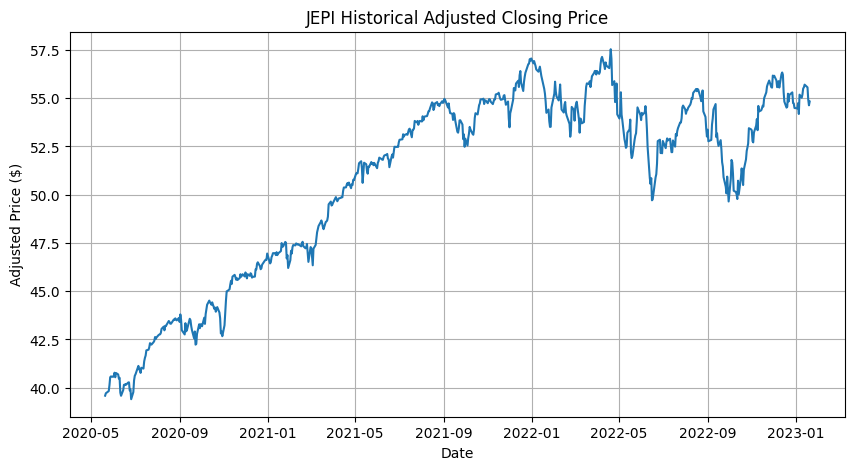

In [12]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Adj Close'])
plt.title('JEPI Historical Adjusted Closing Price')
plt.xlabel('Date')
plt.ylabel('Adjusted Price ($)')
plt.grid(True)
plt.show()

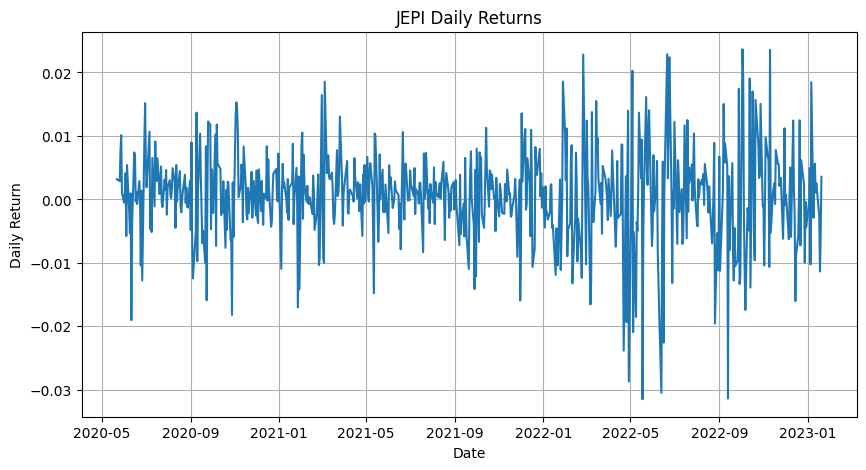

In [13]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Daily Return'])
plt.title('JEPI Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True)
plt.show()

In [15]:
# Current/latest price
S0 = df['Adj Close'].iloc[-1]

# Annualized parameters
mu = annual_return
sigma = annual_volatility

# Simulation settings
trading_days = 252
simulations = 10000
dt = 1 / 252

np.random.seed(42)

price_paths = np.zeros((trading_days + 1, simulations))
price_paths[0] = S0

for t in range(1, trading_days + 1):
    Z = np.random.standard_normal(simulations)

    price_paths[t] = price_paths[t-1] * np.exp(
        (mu - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * Z
    )

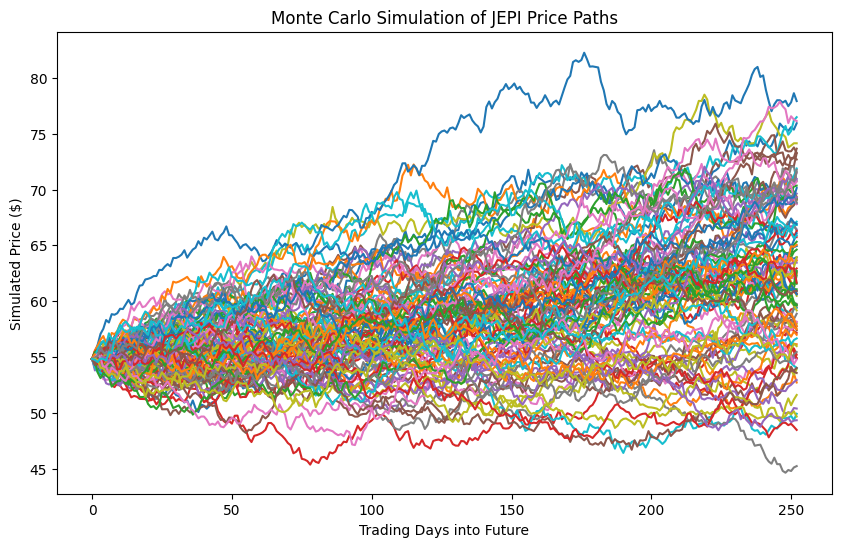

In [16]:
plt.figure(figsize=(10,6))

plt.plot(price_paths[:, :100])

plt.title('Monte Carlo Simulation of JEPI Price Paths')
plt.xlabel('Trading Days into Future')
plt.ylabel('Simulated Price ($)')
plt.show()

In [17]:
ending_prices = price_paths[-1]

mean_ending_price = np.mean(ending_prices)
median_ending_price = np.median(ending_prices)
percentile_5 = np.percentile(ending_prices, 5)
percentile_95 = np.percentile(ending_prices, 95)

print("Current JEPI Price:", S0)
print("Mean Simulated Price After One Year:", mean_ending_price)
print("Median Simulated Price:", median_ending_price)
print("5th Percentile Price:", percentile_5)
print("95th Percentile Price:", percentile_95)

Current JEPI Price: 54.82500076293945
Mean Simulated Price After One Year: 62.33651248249245
Median Simulated Price: 61.938959503332484
5th Percentile Price: 51.05739845020904
95th Percentile Price: 75.05324538706518


In [18]:
probability_loss = np.mean(ending_prices < S0)

print("Probability of finishing below current price:",
      probability_loss)

Probability of finishing below current price: 0.1529


In [19]:
simulated_returns = (ending_prices - S0) / S0

var_95 = np.percentile(simulated_returns, 5)

print("95% Value at Risk:", var_95)

95% Value at Risk: -0.06872051546376318


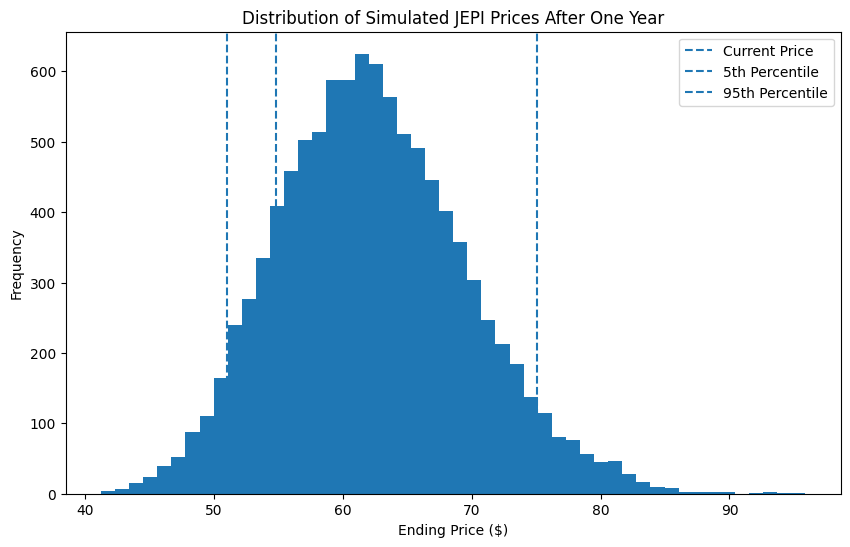

In [20]:
plt.figure(figsize=(10,6))

plt.hist(ending_prices, bins=50)

plt.axvline(S0, linestyle='--',
            label='Current Price')

plt.axvline(percentile_5, linestyle='--',
            label='5th Percentile')

plt.axvline(percentile_95, linestyle='--',
            label='95th Percentile')

plt.title('Distribution of Simulated JEPI Prices After One Year')
plt.xlabel('Ending Price ($)')
plt.ylabel('Frequency')
plt.legend()

plt.show()